Exploratory data analysis

In [ ]:
##Check to see if we are in the correct directory
import os

os.getcwd()

'c:\\Users\\chris\\OneDrive\\Documents\\Universitat de Barcelona\\Automatic-Recognition-of-Microbial-Life\\reports\\notebooks'

In [7]:
import pandas as pd

df = pd.read_parquet("../../data/processed/bacterial_samples.parquet")

df.head()

,raw_file,raw_path,particle_index,timestamp,serial,version,number_of_modules,has_fluorescence,lt11_framelength,lt03_framelength,...,file_id,file_timestamp,filename_parse_ok,sample_type,label,species,fluorophore,mixture_id,mixture_fraction_a,mixture_fraction_b
0,D_000000096_202107081015.raw,data\raw\bacterial_samples\B. cereus\D_0000112...,0,2021-07-08 12:15:00.74,3532891,2,3,True,1680,256,...,000000096,2021-07-08 10:15:00,True,bacterial_sample,D_000011209_202107081015,D_000011209_202107081015,None,None,None,None
1,D_000000096_202107081015.raw,data\raw\bacterial_samples\B. cereus\D_0000112...,1,2021-07-08 12:15:00.86,3532891,2,3,True,1080,256,...,000000096,2021-07-08 10:15:00,True,bacterial_sample,D_000011209_202107081015,D_000011209_202107081015,None,None,None,None
2,D_000000096_202107081015.raw,data\raw\bacterial_samples\B. cereus\D_0000112...,2,2021-07-08 12:15:00.99,3532891,2,3,True,2640,256,...,000000096,2021-07-08 10:15:00,True,bacterial_sample,D_000011209_202107081015,D_000011209_202107081015,None,None,None,None
3,D_000000096_202107081015.raw,data\raw\bacterial_samples\B. cereus\D_0000112...,3,2021-07-08 12:15:00.111,3532891,2,3,True,1032,256,...,000000096,2021-07-08 10:15:00,True,bacterial_sample,D_000011209_202107081015,D_000011209_202107081015,None,None,None,None
4,D_000000096_202107081015.raw,data\raw\bacterial_samples\B. cereus\D_0000112...,4,2021-07-08 12:15:00.124,3532891,2,3,True,1152,256,...,000000096,2021-07-08 10:15:00,True,bacterial_sample,D_000011209_202107081015,D_000011209_202107081015,None,None,None,None


In [8]:
df.columns
df.shape
df["species"].value_counts()

species
D_000011209_202107081015    4794
D_000011210_202107081016    4794
D_000011212_202107081018    4794
D_000011215_202107081021    4794
D_000011217_202107081023    4794
D_000011263_202107081109    4794
D_000011257_202107081103    4794
D_000011259_202107081105    4794
D_000011260_202107081106    4794
D_000011256_202107081102    4794
D_000011262_202107081108    4794
D_000011255_202107081101    4793
D_000011258_202107081104    4793
D_000011211_202107081017    4793
D_000011214_202107081020    4793
D_000011213_202107081019    4793
D_000011216_202107081022    4793
D_000011218_202107081024    4793
D_000011333_202107081219    4793
D_000011329_202107081215    4793
D_000011328_202107081214    4793
D_000011327_202107081213    4793
D_000011330_202107081216    4793
D_000011332_202107081218    4793
D_000011326_202107081212    4793
D_000010931_202107061123    4793
D_000010927_202107061119    4793
D_000010928_202107061120    4793
D_000011261_202107081107    4793
D_000011264_202107081110    4793
D_

In [11]:
df.iloc[0]["spectrometer"]
len(df.iloc[0]["spectrometer"]) ## Check length of spectrometer data for first sample
df["spectrometer"].apply(len).value_counts() ## Check length of spectrometer data for all samples

spectrometer
256    239638
Name: count, dtype: int64

In [13]:
##Create explicit arrays
import numpy as np

X = np.stack(df["spectrometer"].values)
X.shape

(239638, 256)

In [14]:
df.columns

Index(['raw_file', 'raw_path', 'particle_index', 'timestamp', 'serial',
       'version', 'number_of_modules', 'has_fluorescence', 'lt11_framelength',
       'lt03_framelength', 'lt04_framelength', 'image_size',
       'scattering_emitter_id', 'scattering_detection_id', 'scattering_image',
       'spectrometer', 'lifetime', 'crc_ok', 'footer_ok', 'size',
       'time_asymmetry', 'filename', 'parent_folder', 'file_suffix',
       'file_size_bytes', 'sha256', 'file_prefix', 'file_id', 'file_timestamp',
       'filename_parse_ok', 'sample_type', 'label', 'species', 'fluorophore',
       'mixture_id', 'mixture_fraction_a', 'mixture_fraction_b'],
      dtype='object')

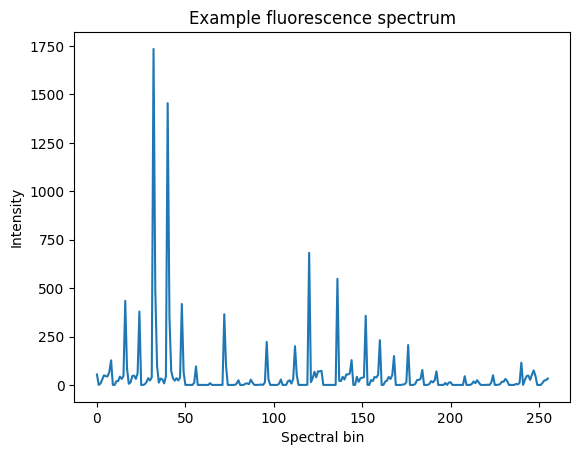

In [15]:
##Visualize Spectra
import matplotlib.pyplot as plt

spec = np.array(df.iloc[0]["spectrometer"])

plt.plot(spec)
plt.xlabel("Spectral bin")
plt.ylabel("Intensity")
plt.title("Example fluorescence spectrum")
plt.show()